# 08 — Full-city reprojection (CV dataset)

Selects one approach-leg photo for **every** Rotterdam intersection with Cyclomedia coverage
and reprojects it to a standardised flat perspective for computer vision (CV) analysis.

Produces ~4,600 images rather than the 145-intersection BT survey subset from notebook 07.

## Leg selection logic (per intersection)
1. **Minimum distance filter** — legs closer than `MIN_PHOTO_DIST_M` are excluded.
   Fallback: if *all* legs are too close, keep all (so the intersection is not lost).
2. **Direction priority** — front > left/right > back.
   Back images show the car boot rather than the road; used only as a last resort
   and flagged with `all_back=True` in the output log.
3. **Distance tiebreak** — closest to the intersection's `ideal_dist_m`
   (20 m for singletons, slightly more for large dual-carriageway clusters).

## Input / Output
**Input:**
- `data/processed/leg_photo_selection_directional.csv` — all legs for all intersections (NB04)
- `data/processed/intersections_merged.gpkg` — provides per-intersection `ideal_dist_m`

**Output:**
- One JPEG per intersection in a dedicated HDD folder (separate from the BT reprojections)
- `data/processed/full_city_leg_selection.csv` — log of selected legs with selection flags

**Depends on:** notebook 04 must be run first.

In [6]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"

# Import shared pipeline constants so changes to pipeline_config.py propagate here
sys.path.insert(0, os.path.join(PROJECT_DIR, "notebooks", "pipeline"))
from pipeline_config import IDEAL_PHOTO_DIST_BASE

# --- Input files ---
LEGS_FILE = os.path.join(PROJECT_DIR, "data", "processed", "leg_photo_selection_directional.csv")
INT_FILE  = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")

# --- Photo roots: try HDD first, fall back to TU Delft server ---
HDD_PHOTO_ROOT    = r"D:\rotterdam_aiis_2025\vault-production\vault_v1\images"
SERVER_PHOTO_ROOT = r"Z:\SLIRotterdam\images"

# --- Output: separate folder from the BT survey reprojections in notebook 07 ---
OUTPUT_DIR = r"D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_full_city"

# CSV log of selected legs (written after selection, before reprojection starts)
OUTPUT_LOG = os.path.join(PROJECT_DIR, "data", "processed", "full_city_leg_selection.csv")

# --- Reprojection parameters (match notebook 07) ---
FOV_DEG     = 90    # horizontal FOV in degrees
OUT_W       = 1500  # output width in pixels
OUT_H       = 1000  # output height before bottom crop
BOTTOM_CROP = 0.88  # keep top 88% — matches panorama output height (880px)

# --- Leg selection parameters ---
MIN_PHOTO_DIST_M = 15  # exclude legs closer than this to avoid extreme close-ups

# Direction priority: front faces the intersection, back shows the car boot
DIRECTION_PREFERENCE = {"front": 0, "left": 1, "right": 2, "back": 3}

# --- Testing mode ---
# Set to an integer to process only N intersections (fast); None = full run (~4,600)
N_INTERSECTIONS = None

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"LEGS_FILE      : {os.path.basename(LEGS_FILE)}")
print(f"OUTPUT_DIR     : {OUTPUT_DIR}")
print(f"OUTPUT_LOG     : {os.path.basename(OUTPUT_LOG)}")
print(f"MIN_PHOTO_DIST : {MIN_PHOTO_DIST_M}m")
print(f"Output size    : {OUT_W} x {int(OUT_H * BOTTOM_CROP)}px  (after crop)")
print(f"N_INTERSECTIONS: {N_INTERSECTIONS or 'all'}")

LEGS_FILE      : leg_photo_selection_directional.csv
OUTPUT_DIR     : D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_full_city
OUTPUT_LOG     : full_city_leg_selection.csv
MIN_PHOTO_DIST : 15m
Output size    : 1500 x 880px  (after crop)
N_INTERSECTIONS: all


In [7]:
# Load all approach-leg candidates — one row per (intersection, leg) with the
# best candidate photo per leg already selected by notebook 04.
legs = pd.read_csv(LEGS_FILE)
print(f"Loaded {len(legs):,} legs across {legs['intersection_id'].nunique():,} intersections")
print(f"\nDirection breakdown (all candidates before selection):")
print(legs["selected_direction"].value_counts().to_string())

# Load per-intersection ideal_dist_m from the merged NWB file.
# For singletons this is 20m (IDEAL_PHOTO_DIST_BASE); for large dual-carriageway
# clusters it is slightly higher because the merged centroid sits further from each
# individual approach road. Using the per-intersection value keeps the distance
# tiebreak consistent with how notebook 04 originally ranked candidate photos.
ints = gpd.read_file(INT_FILE)[["JTE_ID", "ideal_dist_m"]]
legs = legs.merge(
    ints.rename(columns={"JTE_ID": "intersection_id"}),
    on="intersection_id",
    how="left"
)
n_missing = legs["ideal_dist_m"].isna().sum()
legs["ideal_dist_m"] = legs["ideal_dist_m"].fillna(IDEAL_PHOTO_DIST_BASE)

print(f"\nideal_dist_m range: {legs['ideal_dist_m'].min():.1f}–{legs['ideal_dist_m'].max():.1f}m")
if n_missing:
    print(f"  ({n_missing} legs used fallback of {IDEAL_PHOTO_DIST_BASE}m)")

Loaded 12,677 legs across 4,615 intersections

Direction breakdown (all candidates before selection):
selected_direction
front    6596
back     5623
left      320
right     138

ideal_dist_m range: 20.0–35.9m


In [8]:
# Vectorised leg selection — avoids groupby+apply returning a Series, which has
# unstable index behaviour across pandas versions.
#
# Strategy:
# 1. Mark each leg as qualified (photo_dist_m >= MIN_PHOTO_DIST_M).
#    For intersections where NO leg qualifies, mark all legs as in-pool (fallback)
#    so the intersection is never silently dropped from the output.
# 2. Score each in-pool leg: direction rank (primary), distance deviation (secondary).
# 3. Sort so the best leg is first within each intersection, then take one per group.
# 4. Compute diagnostic flags from the original (unfiltered) legs table.

legs["_qualified"]     = legs["photo_dist_m"] >= MIN_PHOTO_DIST_M
legs["_any_qualified"] = legs.groupby("intersection_id")["_qualified"].transform("any")
legs["_in_pool"]       = legs["_qualified"] | ~legs["_any_qualified"]

legs["_dir_rank"] = legs["selected_direction"].map(DIRECTION_PREFERENCE).fillna(3)
legs["_dist_dev"] = (legs["photo_dist_m"] - legs["ideal_dist_m"]).abs()

# Sort so the best leg is first within each intersection, then take one per group
pool     = legs[legs["_in_pool"]].sort_values(["intersection_id", "_dir_rank", "_dist_dev"])
selected = pool.groupby("intersection_id", as_index=False).first()

# Diagnostic flags derived from the full (unfiltered) legs table
all_back_map      = legs.groupby("intersection_id")["selected_direction"].apply(lambda x: (x == "back").all())
used_fallback_map = ~legs.groupby("intersection_id")["_qualified"].any()
selected["all_back"]      = selected["intersection_id"].map(all_back_map)
selected["used_fallback"] = selected["intersection_id"].map(used_fallback_map)

# Drop helper columns used only for scoring
selected = selected.drop(columns=["_dir_rank", "_dist_dev", "_qualified", "_any_qualified", "_in_pool"], errors="ignore")
legs     = legs.drop(columns=["_dir_rank", "_dist_dev", "_qualified", "_any_qualified", "_in_pool"], errors="ignore")

# Optionally limit to N_INTERSECTIONS for test runs
if N_INTERSECTIONS is not None:
    selected = selected.head(N_INTERSECTIONS)
    print(f"TEST MODE: limited to {N_INTERSECTIONS} intersections")

# Save log CSV so the selection is reproducible and can feed downstream CV steps
selected.to_csv(OUTPUT_LOG, index=False)

print(f"Selected {len(selected):,} legs (one per intersection)")
print(f"\nDirection breakdown after selection:")
print(selected["selected_direction"].value_counts().to_string())
print(f"\nAll-back intersections (flagged, still reprojected): {int(selected['all_back'].sum())}")
print(f"Min-dist fallback used (all legs < {MIN_PHOTO_DIST_M}m):       {int(selected['used_fallback'].sum())}")
print(f"\nPhoto distance stats of selected legs:")
print(selected["photo_dist_m"].describe(percentiles=[.05, .25, .5, .75, .95]).round(1))
print(f"\nLog saved to: {OUTPUT_LOG}")

Selected 4,615 legs (one per intersection)

Direction breakdown after selection:
selected_direction
front    4316
back      207
left       53
right      39

All-back intersections (flagged, still reprojected): 170
Min-dist fallback used (all legs < 15m):       14

Photo distance stats of selected legs:
count    4615.0
mean       20.5
std         2.2
min         5.2
5%         17.9
25%        19.2
50%        20.2
75%        21.5
95%        24.5
max        36.4
Name: photo_dist_m, dtype: float64

Log saved to: C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\full_city_leg_selection.csv


In [9]:
def prepare_directional_image(img_array):
    # Resize a flat directional image to the standard output dimensions.
    # All images in leg_photo_selection_directional.csv are is_panorama=False,
    # so no 360-degree rotation is needed — just resize to OUT_W x int(OUT_H * BOTTOM_CROP).
    out_h = int(OUT_H * BOTTOM_CROP)
    img   = Image.fromarray(img_array)
    img   = img.resize((OUT_W, out_h), Image.LANCZOS)
    return np.array(img)


def stitch_and_crop(left_filepath, right_filepath, inter_col_frac):
    # Stitch two adjacent directional images and crop centered on the intersection.
    # Used when requires_stitch=True: the intersection fell off-centre in any single
    # camera view, so notebook 04 flagged that two adjacent cameras should be combined.
    #
    # Steps:
    # 1. Load both images (800x480 native for TU Delft 2024 directional cameras).
    # 2. Concatenate horizontally -> 1600x480.
    # 3. Crop one-camera-width centered on the intersection column (same 90-deg FOV).
    # 4. Upscale to OUT_W x int(OUT_H * BOTTOM_CROP) with LANCZOS.
    #
    # Returns None if either source file is missing; caller falls back to single image.
    if not os.path.exists(left_filepath) or not os.path.exists(right_filepath):
        return None

    left_img  = np.array(Image.open(left_filepath))
    right_img = np.array(Image.open(right_filepath))
    h, w      = left_img.shape[:2]

    # Concatenate: left camera on left, right camera on right (clockwise order from NB04)
    stitched   = np.concatenate([left_img, right_img], axis=1)
    inter_col  = int(inter_col_frac * (2 * w))

    # Crop one camera width centered on the intersection column; clamp to image bounds
    half       = w // 2
    crop_left  = max(0, inter_col - half)
    crop_right = min(stitched.shape[1], crop_left + w)
    crop_left  = max(0, crop_right - w)

    cropped = stitched[:, crop_left:crop_right, :]
    out_h   = int(OUT_H * BOTTOM_CROP)
    return np.array(Image.fromarray(cropped).resize((OUT_W, out_h), Image.LANCZOS))


print(f"Reprojection functions defined.")
print(f"Output dimensions: {OUT_W} x {int(OUT_H * BOTTOM_CROP)}px")

Reprojection functions defined.
Output dimensions: 1500 x 880px


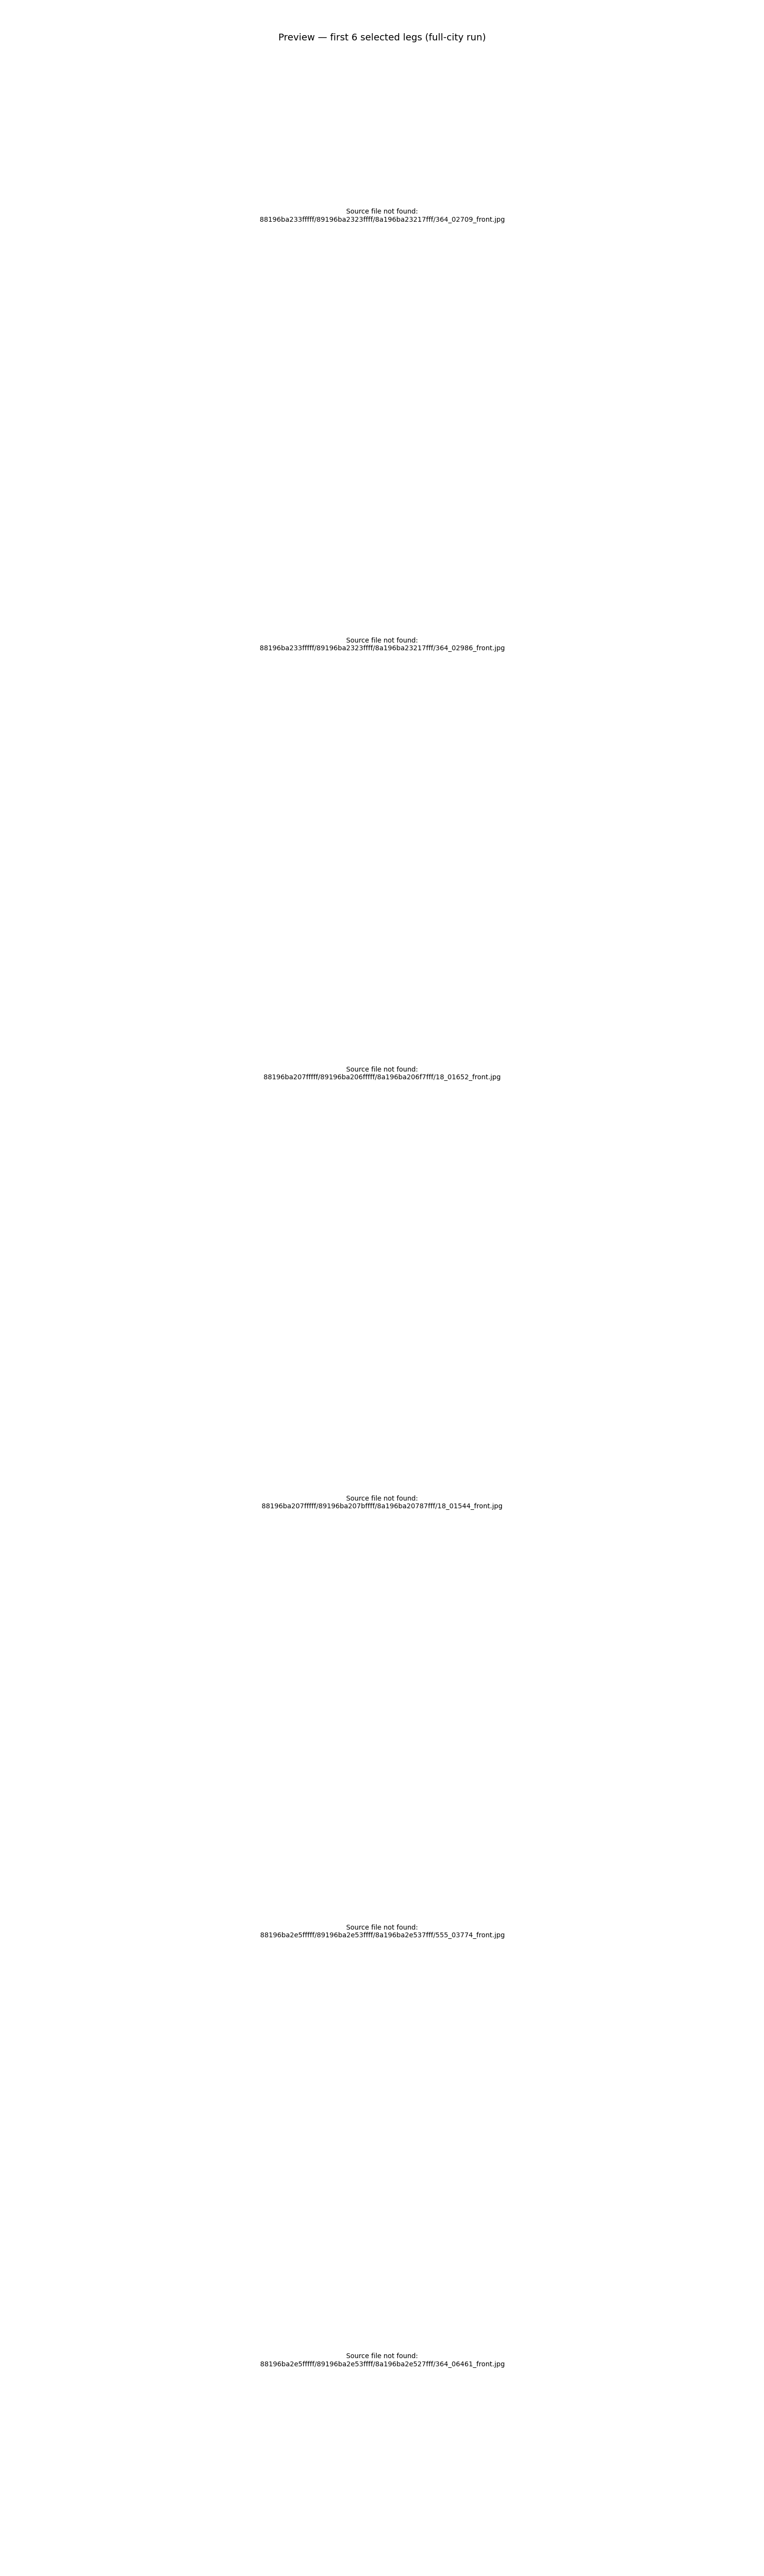

In [10]:
# Preview the first 6 selected legs before committing to a full ~4,600-image run.
# Loads source photos on the fly and processes them so you can verify framing
# and direction-selection logic before starting the long batch.
preview_legs = selected.drop_duplicates("intersection_id").head(6)
fig, axes    = plt.subplots(6, 1, figsize=(16, 54))

for i, (_, leg) in enumerate(preview_legs.iterrows()):
    ax = axes[i]

    rel         = leg["photo_filepath"]
    hdd_path    = os.path.join(HDD_PHOTO_ROOT, rel)
    server_path = os.path.join(SERVER_PHOTO_ROOT, rel)
    src_path    = hdd_path if os.path.exists(hdd_path) else server_path

    if os.path.exists(src_path):
        img = np.array(Image.open(src_path))
        if leg.get("requires_stitch", False):
            pers = stitch_and_crop(
                leg["stitch_left_filepath"],
                leg["stitch_right_filepath"],
                leg["stitch_inter_col_frac"],
            )
            if pers is None:
                pers = prepare_directional_image(img)
            label = "stitched"
        else:
            pers  = prepare_directional_image(img)
            label = leg.get("selected_direction", "directional")
        ax.imshow(pers)
        flags = []
        if leg.get("all_back", False):      flags.append("ALL_BACK")
        if leg.get("used_fallback", False): flags.append("DIST_FALLBACK")
        ax.set_title(
            f"Intersection {leg['intersection_id']} | "
            f"Leg {leg['leg_bearing']:.0f}° | {label} | "
            f"dist={leg['photo_dist_m']:.0f}m | ideal={leg['ideal_dist_m']:.0f}m"
            + (f" | {' '.join(flags)}" if flags else ""),
            fontsize=9
        )
    else:
        ax.text(0.5, 0.5, f"Source file not found:\n{rel}", ha="center", va="center")

    ax.axis("off")

plt.suptitle("Preview — first 6 selected legs (full-city run)", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Process and save all selected legs.
# Resume support: files that already exist on disk are counted as saved and skipped,
# so the run can be interrupted and restarted without reprocessing completed images.
saved   = 0   # images successfully written (or already present from a prior run)
missing = 0   # source photo not found on HDD or server
errors  = 0   # unexpected exception during processing

for i, (_, leg) in enumerate(selected.iterrows()):
    inter_dir = os.path.join(OUTPUT_DIR, str(leg["intersection_id"]))
    out_path  = os.path.join(inter_dir, f"leg_{leg['leg_bearing']:.0f}.jpeg")

    # Skip already-processed images to support resuming interrupted runs
    if os.path.exists(out_path):
        saved += 1
        if (i + 1) % 100 == 0 or (i + 1) == len(selected):
            print(f"  {i+1}/{len(selected)} | saved: {saved} | missing: {missing} | errors: {errors}")
        continue

    # Resolve photo path: prefer HDD, fall back to server
    rel         = leg["photo_filepath"]
    hdd_path    = os.path.join(HDD_PHOTO_ROOT, rel)
    server_path = os.path.join(SERVER_PHOTO_ROOT, rel)
    img_path    = hdd_path if os.path.exists(hdd_path) else server_path

    if not os.path.exists(img_path):
        missing += 1
    else:
        try:
            img = np.array(Image.open(img_path))

            # Stitched path: combine two adjacent cameras and crop to intersection center
            if leg.get("requires_stitch", False):
                pers = stitch_and_crop(
                    leg["stitch_left_filepath"],
                    leg["stitch_right_filepath"],
                    leg["stitch_inter_col_frac"],
                )
                if pers is None:
                    # Stitch source files missing: fall back to single selected image
                    pers = prepare_directional_image(img)
            else:
                # Single directional image: resize to standard output dimensions
                pers = prepare_directional_image(img)

            # Only create the subfolder once an image is ready to save
            os.makedirs(inter_dir, exist_ok=True)
            Image.fromarray(pers).save(out_path, quality=90)
            saved += 1
        except Exception as e:
            print(f"  ERROR intersection {leg['intersection_id']}: {e}")
            errors += 1

    if (i + 1) % 100 == 0 or (i + 1) == len(selected):
        print(f"  {i+1}/{len(selected)} | saved: {saved} | missing: {missing} | errors: {errors}")

display(Markdown(f"**Done.** Saved **{saved}** images to `{OUTPUT_DIR}`"))

  100/4615 | saved: 10 | missing: 90 | errors: 0
  200/4615 | saved: 19 | missing: 181 | errors: 0
  300/4615 | saved: 25 | missing: 275 | errors: 0
  400/4615 | saved: 34 | missing: 366 | errors: 0
  500/4615 | saved: 39 | missing: 461 | errors: 0
  600/4615 | saved: 71 | missing: 529 | errors: 0
  700/4615 | saved: 95 | missing: 605 | errors: 0
  800/4615 | saved: 99 | missing: 701 | errors: 0
  900/4615 | saved: 130 | missing: 770 | errors: 0
  1000/4615 | saved: 138 | missing: 862 | errors: 0
  1100/4615 | saved: 143 | missing: 957 | errors: 0
  1200/4615 | saved: 204 | missing: 996 | errors: 0
  1300/4615 | saved: 229 | missing: 1071 | errors: 0
  1400/4615 | saved: 236 | missing: 1164 | errors: 0
  1500/4615 | saved: 296 | missing: 1204 | errors: 0
  1600/4615 | saved: 304 | missing: 1296 | errors: 0
  1700/4615 | saved: 306 | missing: 1394 | errors: 0
  1800/4615 | saved: 320 | missing: 1480 | errors: 0
  1900/4615 | saved: 367 | missing: 1533 | errors: 0
  2000/4615 | saved: 37

**Done.** Saved **926** images to `D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_full_city`

In [12]:
n_all_back = int(selected["all_back"].sum())
n_fallback = int(selected["used_fallback"].sum())

print("=== Full-city reprojection summary ===")
print(f"Total intersections selected  : {len(selected):,}")
print(f"  Images saved                : {saved:,}")
print(f"  Source photos missing       : {missing:,}")
print(f"  Processing errors           : {errors:,}")
print(f"\nSelection flags:")
print(f"  All-back intersections      : {n_all_back:,}  (reprojected, flagged in log CSV)")
print(f"  Min-dist fallback used      : {n_fallback:,}  (all legs < {MIN_PHOTO_DIST_M}m)")
print(f"\nDirection breakdown of selected legs:")
print(selected["selected_direction"].value_counts().to_string())
print(f"\nOutput folder : {OUTPUT_DIR}")
print(f"Selection log : {OUTPUT_LOG}")

# List all-back intersection IDs for manual review if needed
if n_all_back > 0:
    back_ids = selected[selected["all_back"]]["intersection_id"].tolist()
    print(f"\nAll-back intersection IDs ({len(back_ids)} total):")
    print(back_ids)

=== Full-city reprojection summary ===
Total intersections selected  : 4,615
  Images saved                : 926
  Source photos missing       : 3,689
  Processing errors           : 0

Selection flags:
  All-back intersections      : 170  (reprojected, flagged in log CSV)
  Min-dist fallback used      : 14  (all legs < 15m)

Direction breakdown of selected legs:
selected_direction
front    4316
back      207
left       53
right      39

Output folder : D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_full_city
Selection log : C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections\data\processed\full_city_leg_selection.csv

All-back intersection IDs (170 total):
[176269019, 176273020, 177267087, 177269024, 177273032, 177273071, 178271004, 178271005, 178274059, 179263006, 179263032, 179264015, 179269010, 179273030, 179274020, 179274136, 180269011, 180271033, 180271035, 180271039, 180271099, 180271185, 180272002, 180